In [1]:
# Install project dependencies once from the root: python -m pip install -r requirements.txt

In [2]:
# Dependencies are documented in requirements.txt; this notebook does not install packages on each run.

In [3]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
df = pd.read_excel(PROJECT_ROOT / "data" / "Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [9]:
df[df["Quantity"] < 0]["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [10]:
df[df["UnitPrice"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [12]:
negative_qty = df["Quantity"] < 0

df.loc[negative_qty, "InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [13]:
df[(df["Quantity"] < 0) & 
   (~df["InvoiceNo"].astype(str).str.startswith("C"))].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [14]:
negative_non_c = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

negative_non_c.shape

(1336, 8)

In [15]:
negative_non_c["UnitPrice"].value_counts().head(20)

UnitPrice
0.0    1336
Name: count, dtype: int64

In [16]:
negative_non_c["StockCode"].value_counts().head(20)

StockCode
85175     5
21830     5
85172     4
22719     4
82494L    4
72802C    4
21161     3
22162     3
22034     3
20966     3
22423     3
20892     3
46000S    3
22501     3
22837     3
84631     3
35954     3
84406B    3
22114     3
21621     3
Name: count, dtype: int64

In [17]:
negative_non_c["Description"].isna().value_counts()

Description
True     862
False    474
Name: count, dtype: int64

In [18]:
negative_non_c[
    negative_non_c["Description"].notna()
]["Description"].value_counts().head(20)

Description
check                         120
damages                        45
damaged                        42
?                              41
sold as set on dotcom          20
Damaged                        14
thrown away                     9
Unsaleable, destroyed.          9
??                              7
damages?                        5
wet damaged                     5
ebay                            5
smashed                         4
missing                         3
CHECK                           3
wet pallet                      3
Dotcom sales                    2
reverse 21/5/10 adjustment      2
counted                         2
crushed                         2
Name: count, dtype: int64

In [19]:
negative_non_c[
    negative_non_c["Description"].notna()
]["Quantity"].describe()

count     474.000000
mean     -339.242616
std       920.343402
min     -9600.000000
25%      -256.000000
50%       -72.000000
75%       -28.000000
max        -1.000000
Name: Quantity, dtype: float64

## Now we are working on Invoice level investigation 

In [20]:
negative_non_c["InvoiceNo"].nunique()

1336

In [21]:
negative_invoices = df[df["Quantity"] < 0]["InvoiceNo"].unique()

In [22]:
df[df["InvoiceNo"].isin(negative_invoices)]["Quantity"].gt(0).sum()

np.int64(0)

In [23]:
df[df["UnitPrice"] <= 0]["Quantity"].value_counts().head(20)

Quantity
 1     404
 2     130
 3      84
-1      79
-2      58
-5      46
 4      42
 5      40
-3      39
-6      36
-4      35
-30     32
-9      32
-10     29
 6      29
-7      25
-21     24
 10     22
 8      21
-8      21
Name: count, dtype: int64

In [24]:
df[df["UnitPrice"] <= 0].shape

(2517, 8)

In [25]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)].shape

(1179, 8)

In [26]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)]["Description"].value_counts().head(20)

Description
check                              39
found                              25
adjustment                         14
FRENCH BLUE METAL DOOR SIGN 1       9
amazon                              8
FRENCH BLUE METAL DOOR SIGN 8       8
Found                               8
FRENCH BLUE METAL DOOR SIGN 4       7
FRENCH BLUE METAL DOOR SIGN No      7
OWL DOORSTOP                        7
FRENCH BLUE METAL DOOR SIGN 3       7
RECIPE BOX PANTRY YELLOW DESIGN     7
Amazon                              7
FRENCH BLUE METAL DOOR SIGN 7       6
FRENCH BLUE METAL DOOR SIGN 5       6
FRENCH BLUE METAL DOOR SIGN 6       6
RED KITCHEN SCALES                  6
?                                   6
FRENCH BLUE METAL DOOR SIGN 9       6
MINT KITCHEN SCALES                 6
Name: count, dtype: int64

In [27]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)]["Description"].isna().value_counts()

Description
True     592
False    587
Name: count, dtype: int64

In [28]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0) & (df["Description"].notna())]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    587
Name: count, dtype: int64

In [29]:
zero_price_positive = df[
    (df["UnitPrice"] == 0) &
    (df["Quantity"] > 0)
]

zero_price_positive["InvoiceNo"].nunique()

819

In [30]:
zero_invoices = zero_price_positive["InvoiceNo"].unique()

df[df["InvoiceNo"].isin(zero_invoices)]["UnitPrice"].gt(0).sum()

np.int64(2722)

In [31]:
df[df["InvoiceNo"].isin(zero_invoices)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom


### Calculating Revenue 

In [32]:
zero_price_positive["Quantity"].sum()

np.int64(72603)

In [33]:
zero_price_positive["Quantity"].describe()

count     1179.000000
mean        61.580153
std        453.493889
min          1.000000
25%          1.000000
50%          3.000000
75%         20.000000
max      12540.000000
Name: Quantity, dtype: float64

In [34]:
df_clean = df[df["UnitPrice"] > 0].copy()

In [35]:
df_clean.shape

(539392, 8)

In [36]:
df_clean["CustomerID"].isna().sum()

np.int64(132603)

In [37]:
df_clean["CustomerID"].isna().mean() * 100

np.float64(24.58379063834836)

In [38]:
df_clean[df_clean["CustomerID"].isna()]["Quantity"].mul(
    df_clean[df_clean["CustomerID"].isna()]["UnitPrice"]
).sum()

np.float64(1469806.24)

In [39]:
df_clean[df_clean["CustomerID"].isna()]["Quantity"].lt(0).sum()

np.int64(383)

In [40]:
df_clean[
    (df_clean["CustomerID"].isna()) &
    (df_clean["Quantity"] < 0)
]["Description"].value_counts().head(15)

Description
Manual                                69
SAMPLES                               61
AMAZON FEE                            32
POSTAGE                               29
Bank Charges                          25
PACK OF 72 RETROSPOT CAKE CASES        3
BINGO SET                              2
20 DOLLY PEGS RETROSPOT                2
FRIDGE MAGNETS LA VIE EN ROSE          2
ASSTD FRUIT+FLOWERS FRIDGE MAGNETS     2
ASSORTED COLOUR BIRD ORNAMENT          2
CHRISTMAS METAL TAGS ASSORTED          2
MAGNETS PACK OF 4 SWALLOWS             2
SET/10 RED POLKADOT PARTY CANDLES      2
LUNCH BAG RED RETROSPOT                2
Name: count, dtype: int64

In [41]:
df_clean[df_clean["CustomerID"].isna()]["Country"].value_counts().head(15)

Country
United Kingdom    131125
EIRE                 709
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64

In [42]:
df_clean[df_clean["CustomerID"].isna()]["InvoiceNo"].nunique()

1610

In [43]:
df_clean[df_clean["CustomerID"].isna()]["InvoiceNo"].value_counts().head(10)

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
537434     675
580730     662
538071     651
Name: count, dtype: int64

In [44]:
df_clean.groupby("InvoiceNo")["CustomerID"].apply(lambda x: x.isna().all()).value_counts()

CustomerID
False    22186
True      1610
Name: count, dtype: int64

In [45]:
df_clean[df_clean["CustomerID"].isna()]["Quantity"].mul(
    df_clean[df_clean["CustomerID"].isna()]["UnitPrice"]
).sum()

np.float64(1469806.24)

In [46]:
df_clean["Description"].isna().sum()

np.int64(0)

In [47]:
df["Description"].isna().sum()

np.int64(1454)

In [48]:
df_clean["Quantity"].value_counts().head(15)

Quantity
 1     147823
 2      81699
 12     61044
 6      40839
 4      38442
 3      37037
 24     24005
 10     22266
 8      13108
 5      11717
 48      6059
 25      5119
 20      5000
 16      4260
-1       4105
Name: count, dtype: int64

In [49]:
(df_clean["Quantity"] < 0).sum()

np.int64(9288)

In [50]:
df_clean[df_clean["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True    9288
Name: count, dtype: int64

Negative quantities were investigated and all 9,288 negative-quantity records were associated with invoices beginning with “C”. These records are likely cancellation/return transactions. Therefore, they were retained rather than removed, as returns are important for calculating net sales and understanding customer behavior

In [51]:
(df_clean["Quantity"] == 0).sum()

np.int64(0)

In [52]:
df_clean = df[df["UnitPrice"] > 0].copy()

In [53]:
df_clean["UnitPrice"].describe()

count    539392.000000
mean          4.673648
std          94.614722
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [54]:
df_clean.nlargest(10, "UnitPrice")[["StockCode", "Description", "UnitPrice", "Quantity", "InvoiceNo"]]

,StockCode,Description,UnitPrice,Quantity,InvoiceNo
222681,M,Manual,38970.00,-1,C556445
524602,AMAZONFEE,AMAZON FEE,17836.46,-1,C580605
43702,AMAZONFEE,AMAZON FEE,16888.02,-1,C540117
43703,AMAZONFEE,AMAZON FEE,16453.71,-1,C540118
15016,AMAZONFEE,AMAZON FEE,13541.33,-1,C537630
15017,AMAZONFEE,AMAZON FEE,13541.33,1,537632
16356,AMAZONFEE,AMAZON FEE,13541.33,-1,C537651
16232,AMAZONFEE,AMAZON FEE,13474.79,-1,C537644
524601,AMAZONFEE,AMAZON FEE,11586.50,-1,C580604
299982,B,Adjust bad debt,11062.06,1,A563185


In [55]:
df_clean["StockCode"].value_counts().head(20)

StockCode
85123A    2307
22423     2198
85099B    2156
47566     1726
20725     1639
84879     1501
22197     1476
22720     1473
21212     1385
20727     1350
22383     1347
22457     1280
23203     1266
POST      1252
22386     1251
22469     1237
22960     1228
21931     1214
22086     1210
22411     1202
Name: count, dtype: int64

In [56]:
df_clean[df_clean["StockCode"] == "POST"][
    ["StockCode", "Description", "Quantity", "UnitPrice", "InvoiceNo", "CustomerID"]
].head(10)

,StockCode,Description,Quantity,UnitPrice,InvoiceNo,CustomerID
45,POST,POSTAGE,3,18.0,536370,12583.0
386,POST,POSTAGE,1,15.0,536403,12791.0
1123,POST,POSTAGE,1,18.0,536527,12662.0
5073,POST,POSTAGE,1,18.0,536840,12738.0
5258,POST,POSTAGE,1,18.0,536852,12686.0
5325,POST,POSTAGE,2,40.0,536858,13520.0
5369,POST,POSTAGE,3,18.0,536861,12427.0
6602,POST,POSTAGE,1,18.0,536967,12600.0
6676,POST,POSTAGE,2,18.0,536974,12682.0
6973,POST,POSTAGE,1,18.0,536983,12712.0


In [57]:
df_clean[~df_clean["StockCode"].astype(str).str.match(r"^\d+[A-Za-z]?$")]["StockCode"].value_counts()

StockCode
POST            1252
DOT              707
M                565
15056BL          326
C2               143
D                 77
S                 63
15056bl           62
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20       9
gift_0001_10       8
gift_0001_30       7
DCGS0003           4
gift_0001_50       4
gift_0001_40       3
PADS               3
DCGS0076           2
DCGS0070           1
m                  1
DCGS0069           1
DCGS0004           1
B                  1
Name: count, dtype: int64

In [58]:
df_clean[df_clean["StockCode"].isin(["15056BL", "15056bl"])][
    ["StockCode", "Description", "UnitPrice", "Quantity"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,UnitPrice,Quantity
132,15056BL,EDWARDIAN PARASOL BLACK,5.95,2
110118,15056BL,EDWARDIAN PARASOL BLACK,5.95,10
123870,15056BL,EDWARDIAN PARASOL BLACK,5.95,32
147059,15056BL,EDWARDIAN PARASOL BLACK,5.95,-2
162406,15056BL,EDWARDIAN PARASOL BLACK,5.95,25
171774,15056BL,EDWARDIAN PARASOL BLACK,5.95,18
211919,15056BL,EDWARDIAN PARASOL BLACK,1.95,16
216844,15056BL,EDWARDIAN PARASOL BLACK,5.95,7
217082,15056BL,EDWARDIAN PARASOL BLACK,4.95,-1
233722,15056BL,EDWARDIAN PARASOL BLACK,5.95,5


## StockCode consistency check

The `15056BL` and `15056bl` rows represent the same product: the description is identical, and the UnitPrice pattern is consistent. This is a capitalization inconsistency rather than a separate product.

For analysis, we should normalize the code to one consistent value, but only after checking the actual business meaning. Here, both variants refer to the same item, so we can standardize them for product-level reporting without deleting the raw data.

```python
# Example of the normalization logic
# df_clean['StockCode_clean'] = df_clean['StockCode'].str.upper()
# df_clean.loc[df_clean['StockCode_clean'] == '15056BL', 'StockCode_clean'] = '15056BL'
```


In [59]:
df_clean["StockCode"] = df_clean["StockCode"].astype(str).str.upper()

In [60]:
df_clean.duplicated().sum()

np.int64(5263)

In [61]:
id="4bq72p"
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]

duplicate_rows["InvoiceNo"].nunique()

1929

In [62]:
duplicate_rows["InvoiceNo"].value_counts().head(10)

InvoiceNo
547651    57
579458    53
577482    52
572103    50
574481    49
552285    48
537781    47
555524    40
569897    40
575117    40
Name: count, dtype: int64

In [63]:
df_clean[df_clean["InvoiceNo"] == 547651][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
131911,547651,84795B,SUNSET CHECK HAMMOCK,1,2011-03-24 12:11:00,7.95,16904.0
131912,547651,21922,UNION STRIPE WITH FRINGE HAMMOCK,1,2011-03-24 12:11:00,7.95,16904.0
131913,547651,82613A,"METAL SIGN,CUPCAKE SINGLE HOOK",1,2011-03-24 12:11:00,1.25,16904.0
131914,547651,82613B,"METAL SIGN,CUPCAKE SINGLE HOOK",1,2011-03-24 12:11:00,1.25,16904.0
131915,547651,82613C,"METAL SIGN,CUPCAKE SINGLE HOOK",1,2011-03-24 12:11:00,1.25,16904.0
...,...,...,...,...,...,...,...
132020,547651,85175,CACTI T-LIGHT CANDLES,32,2011-03-24 12:11:00,0.42,16904.0
132021,547651,22968,ROSE COTTAGE KEEPSAKE BOX,1,2011-03-24 12:11:00,9.95,16904.0
132022,547651,22501,PICNIC BASKET WICKER LARGE,1,2011-03-24 12:11:00,9.95,16904.0
132023,547651,22782,SET 3 WICKER STORAGE BASKETS,1,2011-03-24 12:11:00,24.95,16904.0


In [64]:
df_clean[df_clean["InvoiceNo"] == 547651].duplicated().sum()

np.int64(31)

In [65]:
df_clean[df_clean["InvoiceNo"] == 547651].duplicated(keep=False).sum()

np.int64(57)

In [66]:
df_clean[df_clean["InvoiceNo"] == 547651].value_counts().value_counts()

count
1    57
2    22
3     3
4     1
Name: count, dtype: int64

In [67]:
df_clean.duplicated().sum()

np.int64(5263)

In [68]:
df_clean = df_clean.drop_duplicates().copy()

In [69]:
df_clean.shape

(534129, 8)

In [70]:
df_clean.duplicated().sum()


np.int64(0)

In [71]:
df_clean.dtypes


InvoiceNo              object
StockCode                 str
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [72]:
df_clean.isnull().sum()


InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132565
Country             0
dtype: int64

In [73]:
df_clean["CustomerID"].isna().mean() * 100

np.float64(24.818910787468944)

In [74]:
df_clean[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,534129.000000,534129.000000
mean,9.916818,4.695864
std,216.452113,95.079189
min,-80995.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [75]:
df_clean.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308.0
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,16754.0


In [76]:
df_clean[df_clean["InvoiceNo"] == 581483][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0


In [77]:
df_clean[df_clean["StockCode"] == "23843"][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].sort_values("Quantity", ascending=False)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0


In [78]:
df_clean[df_clean["StockCode"] == "23166"][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].sort_values("Quantity", ascending=False)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
285367,561901,23166,MEDIUM CERAMIC TOP STORAGE JAR,288,1.25,14156.0
194462,553607,23166,MEDIUM CERAMIC TOP STORAGE JAR,240,1.04,16684.0
276513,561051,23166,MEDIUM CERAMIC TOP STORAGE JAR,144,1.04,16684.0
485775,577669,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,15567.0
...,...,...,...,...,...,...
203625,C554527,23166,MEDIUM CERAMIC TOP STORAGE JAR,-9,1.04,15251.0
290357,C562375,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,1.25,14911.0
394002,C570867,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,1.25,12607.0
234364,C557508,23166,MEDIUM CERAMIC TOP STORAGE JAR,-240,1.04,16684.0


In [79]:
df_clean[df_clean["Quantity"] >= 10000][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0


In [80]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [81]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [82]:
df_clean[df_clean["InvoiceNo"].astype(str).isin(["541431", "C541433", "581483", "C581484"])][
    ["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]
]

,InvoiceNo,Quantity,UnitPrice,Revenue
61619,541431,74215,1.04,77183.6
61624,C541433,-74215,1.04,-77183.6
540421,581483,80995,2.08,168469.6
540422,C581484,-80995,2.08,-168469.6


In [83]:
df_clean["InvoiceDate"].min(), df_clean["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [84]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

In [85]:
df_clean[["InvoiceDate", "YearMonth"]].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [86]:
monthly_sales = df_clean.groupby("YearMonth")["Revenue"].sum()

In [87]:
monthly_sales

YearMonth
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

In [88]:
monthly_sales.pct_change() * 100


YearMonth
2010-12          NaN
2011-01   -25.213486
2011-02   -10.998712
2011-03    37.218861
2011-04   -27.806782
2011-05    46.657446
2011-06    -4.447740
2011-07    -1.423270
2011-08     3.433559
2011-09    44.645541
2011-10     5.087629
2011-11    36.168792
2011-12   -70.284496
Freq: M, Name: Revenue, dtype: float64

In [89]:
monthly_orders = df_clean.groupby("YearMonth")["InvoiceNo"].nunique()
monthly_orders

YearMonth
2010-12    1885
2011-01    1346
2011-02    1319
2011-03    1772
2011-04    1486
2011-05    1995
2011-06    1862
2011-07    1745
2011-08    1639
2011-09    2170
2011-10    2402
2011-11    3210
2011-12     965
Freq: M, Name: InvoiceNo, dtype: int64

In [90]:
revenue_per_invoice = monthly_sales / monthly_orders
revenue_per_invoice

YearMonth
2010-12    396.139846
2011-01    414.894918
2011-02    376.820629
2011-03    384.883736
2011-04    331.337713
2011-05    361.951930
2011-06    370.557052
2011-07    389.774780
2011-08    429.231592
2011-09    468.938563
2011-10    445.199097
2011-11    453.627975
2011-12    448.394881
Freq: M, dtype: float64

## Continue monthly analysis: sales invoices and cancellations

The earlier `monthly_orders` counts **all retained invoices**, including cancellations. Consequently, `revenue_per_invoice` is net revenue per recorded invoice, not average order value. We preserve that exploratory calculation and clarify its meaning here.

First, run the proposed non-C invoice count using the existing `df_clean` and `YearMonth`. No cleaning or revenue features are recreated. The original dataset remains unchanged.


In [91]:
monthly_sales_invoices = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
].groupby("YearMonth")["InvoiceNo"].nunique()

monthly_sales_invoices

YearMonth
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

### Check what the non-C definition includes

A non-C invoice is not automatically a normal sale. Inspect other invoice formats before using this count as an order denominator. Digit-only invoice numbers with positive quantities will be our operational definition of normal sales; this still includes retained postage, fees and other special lines, so it is not a merchandise-only basket measure.


In [92]:
invoice_text = df_clean["InvoiceNo"].astype(str)
is_cancellation = invoice_text.str.startswith("C")
is_normal_sale = invoice_text.str.fullmatch(r"\d+") & df_clean["Quantity"].gt(0)
is_other_record = ~(is_cancellation | is_normal_sale)

other_invoice_records = df_clean.loc[
    is_other_record,
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "Revenue", "YearMonth"]
]
other_invoice_records

,InvoiceNo,Description,Quantity,UnitPrice,Revenue,YearMonth
299982,A563185,Adjust bad debt,1,11062.06,11062.06,2011-08


**Observed:** the non-C count includes invoice `A563185`, an August 2011 “Adjust bad debt” record with positive revenue of £11,062.06. It survived the existing positive-price filter. Keep it in `df_clean`, but report it separately from normal sales. Thus August has 1,361 non-C invoices and 1,360 normal sales invoices.

After duplicate removal there are 9,251 negative-quantity rows; the earlier 9,288 figure describes the stage before duplicate removal. The cleaned dataset still has 534,129 rows (now 10 columns because Revenue and YearMonth were added).

### Define the monthly measures

- **Gross sales revenue:** revenue on normal sales invoices, before cancellations.
- **Cancellation value:** the positive magnitude of revenue reversed by C-prefix records; these include operational credits as well as product returns.
- **Net revenue:** the existing `monthly_sales`, including the separately identified adjustment.
- **Gross revenue per sales invoice:** gross sales revenue divided by normal sales invoices. This describes recorded invoice value before cancellations, including special lines.
- **Net revenue per sales invoice:** existing net revenue divided by normal sales invoices. This is a period-level ratio, not the average final value of matched orders: credits may relate to earlier months and accounting adjustments remain in its numerator.

The previously investigated extreme sale/cancellation pairs remain intact. Their net contributions offset, but they can still inflate gross invoice averages. A C-invoice count divided by sales-invoice count would not measure the fraction of orders returned without matching original orders.


In [93]:
monthly_normal_sales_invoices = df_clean.loc[is_normal_sale].groupby("YearMonth")["InvoiceNo"].nunique()
monthly_cancellation_invoices = df_clean.loc[is_cancellation].groupby("YearMonth")["InvoiceNo"].nunique()
monthly_gross_sales = df_clean.loc[is_normal_sale].groupby("YearMonth")["Revenue"].sum()
monthly_cancellation_value = -df_clean.loc[is_cancellation].groupby("YearMonth")["Revenue"].sum()
monthly_adjustments = df_clean.loc[is_other_record].groupby("YearMonth")["Revenue"].sum()

monthly_invoice_summary = pd.DataFrame({
    "Sales invoices": monthly_normal_sales_invoices,
    "Cancellation invoices": monthly_cancellation_invoices,
    "Gross sales (GBP)": monthly_gross_sales,
    "Cancellation value (GBP)": monthly_cancellation_value,
    "Other adjustments (GBP)": monthly_adjustments.reindex(monthly_sales.index, fill_value=0),
    "Net revenue (GBP)": monthly_sales,
})
monthly_revenue_per_sales_invoice = monthly_sales / monthly_normal_sales_invoices
monthly_invoice_summary["Gross revenue per sales invoice (GBP)"] = monthly_gross_sales / monthly_normal_sales_invoices
monthly_invoice_summary["Net revenue per sales invoice (GBP)"] = monthly_revenue_per_sales_invoice
monthly_invoice_summary["Coverage"] = "Full calendar month in observed range"
last_observed_date = df_clean["InvoiceDate"].max()
if last_observed_date.day < last_observed_date.days_in_month:
    monthly_invoice_summary.loc[last_observed_date.to_period("M"), "Coverage"] = "Partial: through " + str(last_observed_date)

monthly_invoice_summary.round(2)

,Sales invoices,Cancellation invoices,Gross sales (GBP),Cancellation value (GBP),Other adjustments (GBP),Net revenue (GBP),Gross revenue per sales invoice (GBP),Net revenue per sales invoice (GBP),Coverage
YearMonth,,,,,,,,,
2010-12,1559,326,821452.73,74729.12,0.00,746723.61,526.91,478.98,Full calendar month in observed range
2011-01,1086,260,689811.61,131363.05,0.00,558448.56,635.19,514.23,Full calendar month in observed range
2011-02,1100,219,522545.56,25519.15,0.00,497026.41,475.04,451.84,Full calendar month in observed range
2011-03,1454,318,716215.26,34201.28,0.00,682013.98,492.58,469.06,Full calendar month in observed range
2011-04,1246,240,536968.49,44600.65,0.00,492367.84,430.95,395.16,Full calendar month in observed range
2011-05,1681,314,769296.61,47202.51,0.00,722094.10,457.64,429.56,Full calendar month in observed range
2011-06,1533,329,760547.01,70569.78,0.00,689977.23,496.12,450.08,Full calendar month in observed range
2011-07,1475,270,718076.12,37919.13,0.00,680156.99,486.83,461.12,Full calendar month in observed range
2011-08,1360,278,746779.32,54330.80,11062.06,703510.58,549.10,517.29,Full calendar month in observed range


### Reconcile the definitions

These checks ensure every retained row is classified, cancellation signs agree with the data, and the three revenue components recover the original monthly net revenue. Missing customer IDs and special StockCodes remain in the main dataset.


In [94]:
assert df_clean.shape == (534129, 10)
assert df_clean["CustomerID"].isna().sum() == 132565
assert df_clean.loc[is_cancellation, "Quantity"].lt(0).all()
assert (is_cancellation.astype(int) + is_normal_sale.astype(int) + is_other_record.astype(int)).eq(1).all()
reconciled_revenue = (
    monthly_invoice_summary["Gross sales (GBP)"]
    - monthly_invoice_summary["Cancellation value (GBP)"]
    + monthly_invoice_summary["Other adjustments (GBP)"]
)
assert (reconciled_revenue - monthly_sales).abs().lt(0.000001).all()
monthly_other_invoices = df_clean.loc[is_other_record].groupby("YearMonth")["InvoiceNo"].nunique().reindex(monthly_sales.index, fill_value=0)
assert (monthly_normal_sales_invoices + monthly_cancellation_invoices + monthly_other_invoices).eq(monthly_orders).all()
print("Checks passed: invoice counts and monthly revenue reconcile; retained customer coverage is unchanged.")

Checks passed: invoice counts and monthly revenue reconcile; retained customer coverage is unchanged.


### Interpretation and next step

November 2011 has **2,769 normal sales invoices**, gross revenue per sales invoice of **£543.11**, and net revenue per sales invoice of **£525.87**. The difference reflects cancellation value recorded during November, not necessarily returns against November orders.

December 2011 ends at **2011-12-09 12:50**. Its total revenue and invoice count must not be compared with full months as evidence of a business decline. The earlier -70.28% month-over-month result is an incomplete-period comparison. Even per-invoice ratios may reflect a different mix of trading days and unusually large reversed transactions.

This completes the next monthly invoice-analysis step. Next, investigate invoice-value distributions and the contribution of special StockCodes before drawing conclusions about typical customer baskets. The later product, customer/RFM, country and dashboard stages remain future work; they have not been inferred from these aggregate results.


## Complete the retail analysis

The preceding cells are the original investigation and monthly invoice continuation. This section completes the remaining project goals using shared functions in `src/retail.py`. The dashboard imports those same definitions. The raw workbook and main `df_clean` are preserved; additional features are created on an analysis copy.

The notebook's cleaning sequence is now reproducible in a shared function. First verify that it produces **exactly** the same dataframe, rather than silently replacing the earlier cleaning decisions.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from src.retail import (clean_transactions, analysis_view, kpis, performance,
    monthly_performance, basket_summary, customer_summary, rfm_snapshot)

pd.testing.assert_frame_equal(df_clean, clean_transactions(df))
retail = analysis_view(df_clean)
coverage_start = retail.Date.min().date()
coverage_end = retail.Date.max().date()
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
retail[["InvoiceDate", "YearMonth", "Year", "Month", "Week", "DayOfWeek", "Hour", "TransactionType", "ProductScope"]].head()

,InvoiceDate,YearMonth,Year,Month,Week,DayOfWeek,Hour,TransactionType,ProductScope
0,2010-12-01 08:26:00,2010-12,2010,12,2010-11-29,Wednesday,8,Sale,Catalog products
1,2010-12-01 08:26:00,2010-12,2010,12,2010-11-29,Wednesday,8,Sale,Catalog products
2,2010-12-01 08:26:00,2010-12,2010,12,2010-11-29,Wednesday,8,Sale,Catalog products
3,2010-12-01 08:26:00,2010-12,2010,12,2010-11-29,Wednesday,8,Sale,Catalog products
4,2010-12-01 08:26:00,2010-12,2010,12,2010-11-29,Wednesday,8,Sale,Catalog products


### Time patterns: weekly, daily, weekday and hourly

`Week` is the Monday of the calendar week, avoiding ambiguous week numbers across years. These are recorded transaction totals. Boundary weeks can be partial, and missing trading days do not prove zero demand. Weekday/hour totals are not exposure-adjusted. The original monthly net revenue and invoice analysis above is reused; comparable growth excludes partial months.

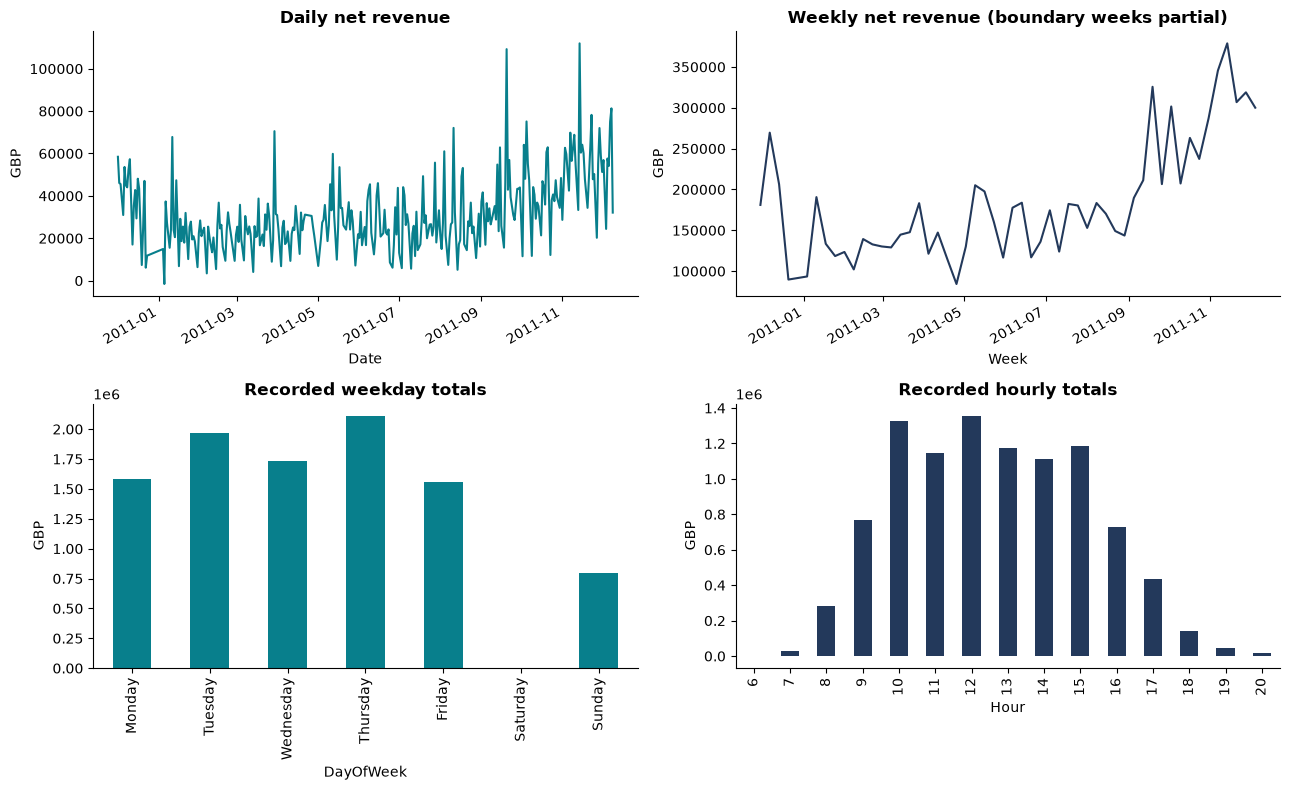

,NetRevenue,SalesInvoices,NetRevenuePerSalesInvoice,CompleteMonth,MoMPercent
YearMonth,,,,,
2010-12,746723.61,1559,478.98,True,NaN
2011-01,558448.56,1086,514.23,True,-25.21
2011-02,497026.41,1100,451.84,True,-11.00
2011-03,682013.98,1454,469.06,True,37.22
2011-04,492367.84,1246,395.16,True,-27.81
2011-05,722094.10,1681,429.56,True,46.66
2011-06,689977.23,1533,450.08,True,-4.45
2011-07,680156.99,1475,461.12,True,-1.42
2011-08,703510.58,1360,517.29,True,3.43


In [96]:
daily_performance = performance(retail, "Date")
weekly_performance = performance(retail, "Week")
hourly_performance = performance(retail, "Hour")
weekday_performance = performance(retail, "DayOfWeek").reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
comparable_monthly = monthly_performance(retail, coverage_start, coverage_end)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
daily_performance.NetRevenue.plot(ax=axes[0, 0], color="#087F8C", title="Daily net revenue")
weekly_performance.NetRevenue.plot(ax=axes[0, 1], color="#23395B", title="Weekly net revenue (boundary weeks partial)")
weekday_performance.NetRevenue.plot.bar(ax=axes[1, 0], color="#087F8C", title="Recorded weekday totals")
hourly_performance.NetRevenue.plot.bar(ax=axes[1, 1], color="#23395B", title="Recorded hourly totals")
for ax in axes.flat: ax.set_ylabel("GBP")
fig.tight_layout()
plt.show()
display(comparable_monthly[["NetRevenue", "SalesInvoices", "NetRevenuePerSalesInvoice", "CompleteMonth", "MoMPercent"]].round(2))

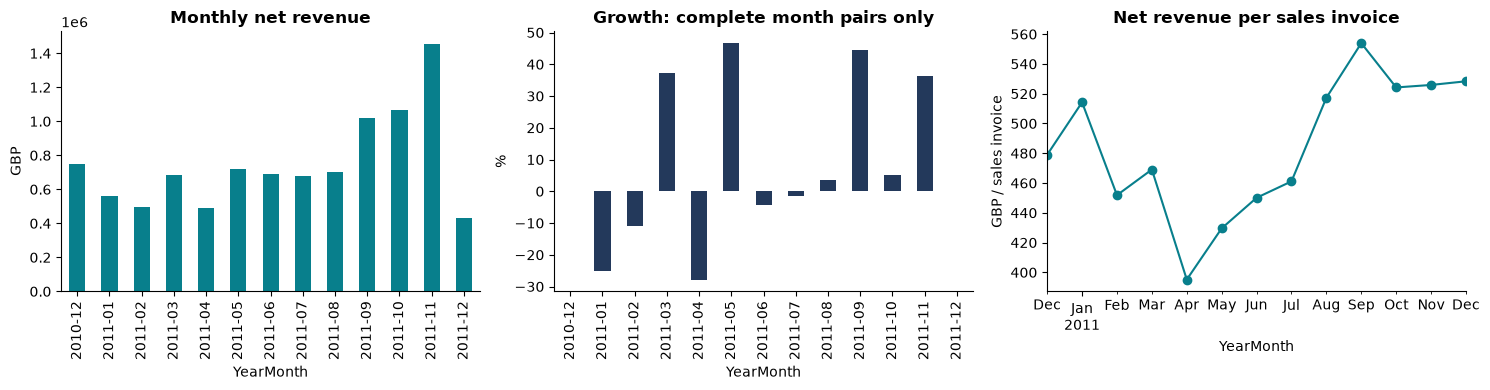

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparable_monthly.NetRevenue.plot.bar(ax=axes[0], color="#087F8C", title="Monthly net revenue")
comparable_monthly.MoMPercent.plot.bar(ax=axes[1], color="#23395B", title="Growth: complete month pairs only")
comparable_monthly.NetRevenuePerSalesInvoice.plot(ax=axes[2], marker="o", color="#087F8C", title="Net revenue per sales invoice")
axes[0].set_ylabel("GBP")
axes[1].set_ylabel("%")
axes[2].set_ylabel("GBP / sales invoice")
fig.tight_layout()
plt.show()

### Product analysis and special records

A five-digit StockCode with optional letters is used as a **catalog-product proxy**, not proof of a physical item. This includes `15056BL`, whose case variants were investigated earlier. Other codes are classified as “Special / review” and retained in all-business net revenue. No row is deleted for failing this pattern.

Use net revenue for contribution, positive sales quantity for gross units sold, and cancellation quantity/value separately. Revenue shares use the catalog subset as denominator; credits can create negative shares. Review descriptions before treating an unfamiliar code as merchandise.

,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct,Description
StockCode,,,,,,,,,,,,,,
22423,164459.49,174156.54,9697.05,0.0,12996,13851,855,1988,881,180,82.73,5.57,1.68,REGENCY CAKESTAND 3 TIER
85123A,99790.93,106415.23,6624.30,0.0,35355,37933,2578,2265,856,42,44.06,6.22,1.02,WHITE HANGING HEART T-LIGHT HOLDER
47566,98243.88,99445.23,1201.35,0.0,18006,18283,277,1685,708,20,58.30,1.21,1.01,PARTY BUNTING
85099B,92175.79,94159.81,1984.02,0.0,47256,48371,1115,2089,635,43,44.12,2.11,0.94,JUMBO BAG RED RETROSPOT
23084,66661.63,66870.03,208.40,0.0,30631,30739,108,994,450,15,67.06,0.31,0.68,RABBIT NIGHT LIGHT
22086,63715.24,64875.59,1160.35,0.0,18876,19329,453,1160,613,10,54.93,1.79,0.65,PAPER CHAIN KIT 50'S CHRISTMAS
84879,58792.42,58927.62,135.20,0.0,36282,36362,80,1455,678,12,40.41,0.23,0.60,ASSORTED COLOUR BIRD ORNAMENT
79321,53746.66,54096.36,349.70,0.0,10222,10302,80,661,205,6,81.31,0.65,0.55,CHILLI LIGHTS
22502,51023.52,51408.77,385.25,0.0,1862,1937,75,463,175,9,110.20,0.75,0.52,PICNIC BASKET WICKER SMALL


,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct
StockCode,,,,,,,,,,,,,
DOT,206245.48,206248.77,3.29,0.00,705,706,1,706,1,1,292.13,0.00,-905.04
POST,66230.64,78101.88,11871.24,0.00,3003,3150,147,1126,331,124,58.82,15.20,-290.63
B,11062.06,0.00,0.00,11062.06,1,0,0,0,0,0,NaN,NaN,-48.54
C2,6986.00,7051.00,65.00,0.00,140,142,2,141,29,2,49.55,0.92,-30.66
GIFT_0001_30,175.53,175.53,0.00,0.00,7,7,0,7,0,0,25.08,0.00,-0.77
GIFT_0001_50,167.56,167.56,0.00,0.00,4,4,0,4,0,0,41.89,0.00,-0.74
GIFT_0001_20,167.05,167.05,0.00,0.00,10,10,0,9,0,0,18.56,0.00,-0.73
DCGSSBOY,150.55,150.55,0.00,0.00,47,47,0,11,0,0,13.69,0.00,-0.66
DCGSSGIRL,144.43,144.43,0.00,0.00,47,47,0,13,0,0,11.11,0.00,-0.63


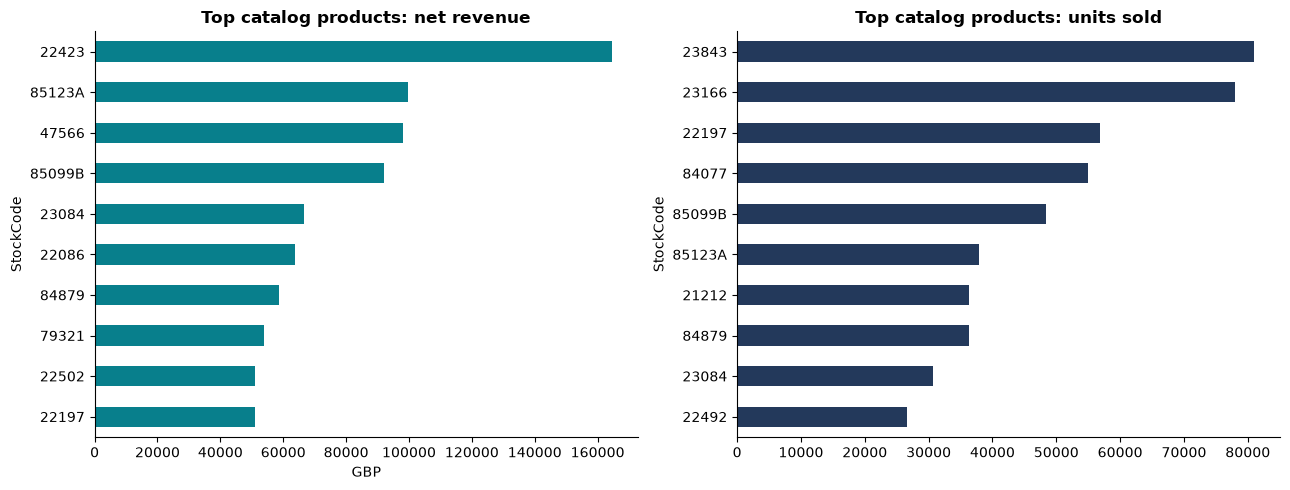

In [98]:
catalog = retail.loc[retail.ProductScope.eq("Catalog products")]
product_performance = performance(catalog, "StockCode").sort_values("NetRevenue", ascending=False)
product_descriptions = retail.drop_duplicates("StockCode").set_index("StockCode").Description
product_performance["Description"] = product_performance.index.map(product_descriptions)
special_records = performance(retail.loc[retail.ProductScope.eq("Special / review")], "StockCode")
display(product_performance.head(15).round(2))
display(special_records.sort_values("NetRevenue", ascending=False).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
product_performance.head(10).sort_values("NetRevenue").NetRevenue.plot.barh(ax=axes[0], color="#087F8C", title="Top catalog products: net revenue")
product_performance.nlargest(10, "SoldUnits").sort_values("SoldUnits").SoldUnits.plot.barh(ax=axes[1], color="#23395B", title="Top catalog products: units sold")
axes[0].set_xlabel("GBP")
fig.tight_layout()
plt.show()

### Customer spending and repeat purchasing

Customer analysis requires a valid CustomerID, but unidentified transactions remain in retail totals. Frequency counts distinct normal sales invoices, not product lines. Repeat purchasers have at least two such invoices in the observation window. Customers appearing only in cancellations are included in the activity table, with zero sales frequency; they are excluded from the repeat-purchaser denominator.

Identified purchasing customers       4338.00
Cancellation-only customers             33.00
Repeat purchasers                     2845.00
Repeat purchaser share (%)              65.58
Unidentified line share (%)             24.82
Unidentified net revenue (GBP)     1469611.65
dtype: float64

,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct,RepeatPurchaser
CustomerID,,,,,,,,,,,,,,
14646,279489.02,280206.02,717.00,0.0,196143,196915,772,73,1,3,3828.62,0.26,3.38,True
18102,256438.49,259657.30,3218.81,0.0,64122,64124,2,60,1,2,4273.97,1.24,3.10,True
17450,187322.17,194390.79,7068.62,0.0,69009,69973,964,46,1,9,4072.22,3.64,2.26,True
14911,132458.73,143711.17,11252.44,0.0,76905,80240,3335,201,1,47,659.00,7.83,1.60,True
12415,123725.45,124914.53,1189.08,0.0,76946,77374,428,21,1,5,5891.69,0.95,1.49,True
14156,113214.59,117210.08,3995.49,0.0,56908,57768,860,55,1,11,2058.45,3.41,1.37,True
17511,88125.38,91062.38,2937.00,0.0,63012,64549,1537,31,1,15,2842.75,3.23,1.06,True
16684,65892.08,66653.56,761.48,0.0,49390,50255,865,28,1,3,2353.29,1.14,0.80,True
13694,62690.54,65039.62,2349.08,0.0,61899,63312,1413,50,1,10,1253.81,3.61,0.76,True


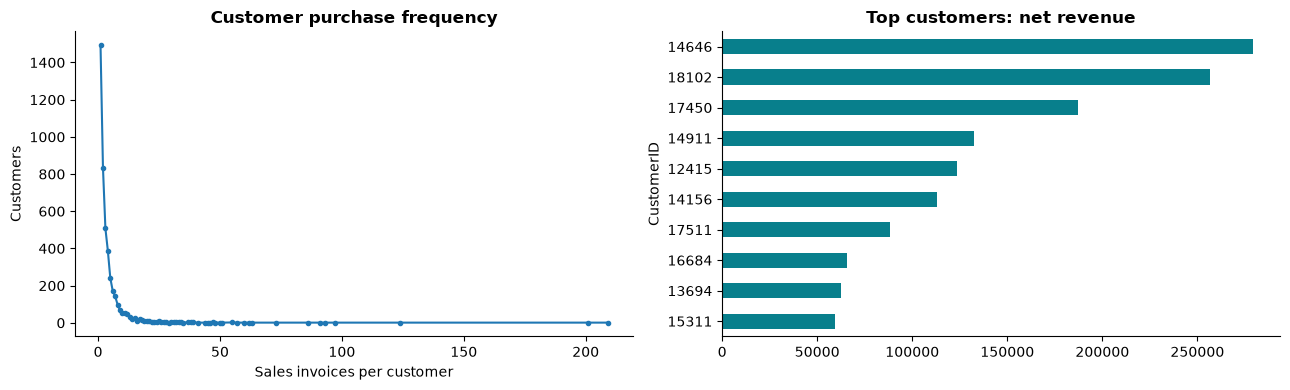

In [99]:
customers_analysis = customer_summary(retail)
purchasers = customers_analysis.loc[customers_analysis.SalesInvoices.gt(0)]
customer_coverage = pd.Series({
    "Identified purchasing customers": len(purchasers),
    "Cancellation-only customers": int(customers_analysis.SalesInvoices.eq(0).sum()),
    "Repeat purchasers": int(purchasers.RepeatPurchaser.sum()),
    "Repeat purchaser share (%)": purchasers.RepeatPurchaser.mean() * 100,
    "Unidentified line share (%)": retail.CustomerID.isna().mean() * 100,
    "Unidentified net revenue (GBP)": retail.loc[retail.CustomerID.isna(), "Revenue"].sum(),
})
display(customer_coverage.round(2))
display(customers_analysis.sort_values("NetRevenue", ascending=False).head(15).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
purchasers.SalesInvoices.value_counts().sort_index().plot(ax=axes[0], marker=".", title="Customer purchase frequency")
axes[0].set_xlabel("Sales invoices per customer")
axes[0].set_ylabel("Customers")
customers_analysis.nlargest(10, "NetRevenue").sort_values("NetRevenue").NetRevenue.plot.barh(ax=axes[1], color="#087F8C", title="Top customers: net revenue")
fig.tight_layout()
plt.show()

### RFM segmentation: transparent, descriptive rules

Use all available history through the snapshot end date and a reference date one day later. Eligible customers have an ID and at least one normal sales invoice. **Recency** is days since last purchase; **Frequency** counts sales invoices; **Monetary** includes sales and C-invoice credits, excluding accounting adjustments. Credit-only customers are not scored. A last purchase later reversed is still a recorded purchase; we do not have reliable order-level matching for all returns.

Scores are `ceil(average percentile rank × 5)`, clipped to 1–5. Lower Recency gets a higher score. Equal values receive equal scores, so groups need not be equal-sized. This avoids arbitrarily splitting tied frequencies by CustomerID.

Rules are evaluated in this order:

| Segment | Rule | Possible business action |
|---|---|---|
| Net non-positive | Monetary ≤ 0 | Review credit/reversal context before targeting |
| Champions | R, F, M ≥ 4 | Test retention and relevant cross-sell offers |
| At-risk loyal | R ≤ 2 and F ≥ 4 | Investigate lapse and test reactivation |
| Loyal | R ≥ 3 and F ≥ 4 | Maintain service and repeat-purchase experience |
| Recent occasional | R ≥ 4 and F ≤ 2 | Test a second-purchase journey |
| Dormant | R ≤ 2 | Evaluate low-cost reactivation |
| Developing | Remaining eligible customers | Learn preferences before targeted offers |

These are descriptive segments, not a validated churn or lifetime-value model. Actions are hypotheses to test, not guaranteed effects.

,Customers,MedianRecency,MedianFrequency,NetMonetary,MedianMonetary
Segment,,,,,
At-risk loyal,210,108.0,5.0,378609.77,1414.36
Champions,912,11.0,8.0,5506449.42,2661.88
Developing,1079,37.0,2.0,777052.08,525.69
Dormant,1505,193.0,1.0,789130.81,327.97
Loyal,380,41.0,5.0,765126.50,1240.40
Net non-positive,16,139.0,1.0,-2817.90,-4.08
Recent occasional,236,20.0,1.0,75379.98,226.38


,LastPurchase,Frequency,Recency,Monetary,R,F,M,RFMScore,Segment
CustomerID,,,,,,,,,
14646,2011-12-08 12:12:00,73,2,279489.02,5,5,5,555,Champions
18102,2011-12-09 11:50:00,60,1,256438.49,5,5,5,555,Champions
17450,2011-12-01 13:29:00,46,9,187322.17,5,5,5,555,Champions
14911,2011-12-08 15:54:00,201,2,132458.73,5,5,5,555,Champions
12415,2011-11-15 14:22:00,21,25,123725.45,4,5,5,455,Champions
14156,2011-11-30 10:54:00,55,10,113214.59,5,5,5,555,Champions
17511,2011-12-07 10:12:00,31,3,88125.38,5,5,5,555,Champions
16684,2011-12-05 14:06:00,28,5,65892.08,5,5,5,555,Champions
13694,2011-12-06 09:32:00,50,4,62690.54,5,5,5,555,Champions


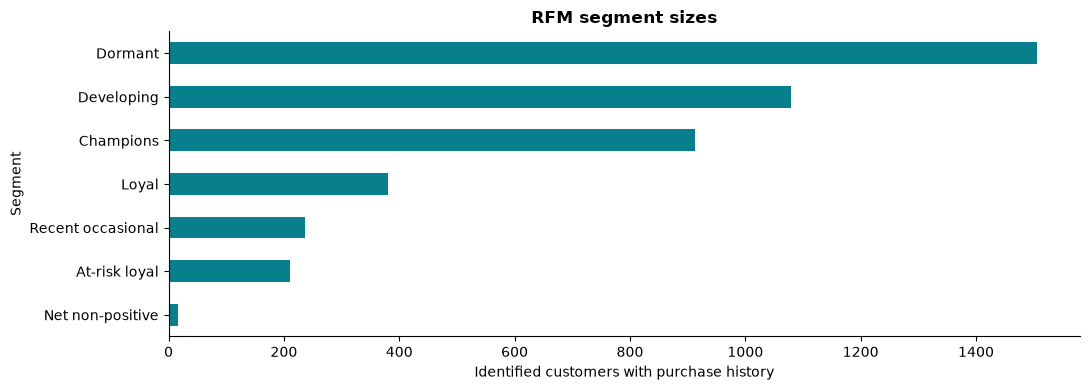

In [100]:
rfm = rfm_snapshot(retail, coverage_end)
segment_summary = rfm.groupby("Segment").agg(Customers=("Frequency", "size"),
    MedianRecency=("Recency", "median"), MedianFrequency=("Frequency", "median"),
    NetMonetary=("Monetary", "sum"), MedianMonetary=("Monetary", "median"))
display(segment_summary.round(2))
display(rfm.sort_values("Monetary", ascending=False).head(15))
segment_summary.Customers.sort_values().plot.barh(color="#087F8C", title="RFM segment sizes")
plt.xlabel("Identified customers with purchase history")
plt.tight_layout()
plt.show()

### Country performance

Compare recorded markets using net revenue, sales invoices, identified purchasing customers and units. Country-level customer counts need not sum to the global total because a customer can appear in multiple countries. Revenue concentration is descriptive; it is not evidence that an overseas market is unprofitable or underdeveloped.

,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct
Country,,,,,,,,,,,,,
United Kingdom,8189252.30,8990682.03,812491.79,11062.06,4385862,4646905,261044,18018,3920,3372,454.50,9.04,84.01
Netherlands,284661.54,285446.34,784.80,0.00,199552,200361,809,94,9,6,3028.31,0.27,2.92
EIRE,262993.38,283140.52,20147.14,0.00,142221,147007,4786,288,3,72,913.17,7.12,2.70
Germany,221509.47,228678.40,7168.93,0.00,117339,119154,1815,457,94,146,484.70,3.13,2.27
France,197317.11,209625.37,12308.26,0.00,110437,112060,1623,392,87,69,503.36,5.87,2.02
Australia,137009.77,138453.81,1444.04,0.00,83335,83891,556,57,9,12,2403.68,1.04,1.41
Switzerland,56363.05,57067.60,704.55,0.00,30312,30617,305,54,21,20,1043.76,1.23,0.58
Spain,54756.03,61558.56,6802.53,0.00,26806,27933,1127,90,30,15,608.40,11.05,0.56
Belgium,40910.96,41196.34,285.38,0.00,23152,23237,85,98,25,21,417.46,0.69,0.42


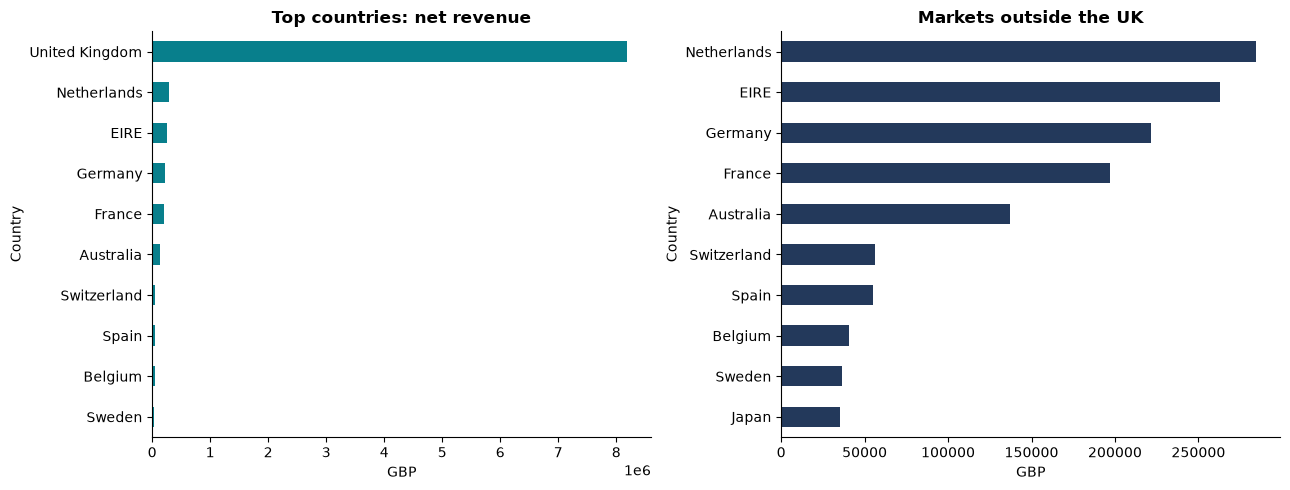

In [101]:
country_performance = performance(retail, "Country").sort_values("NetRevenue", ascending=False)
display(country_performance.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
country_performance.head(10).sort_values("NetRevenue").NetRevenue.plot.barh(ax=axes[0], color="#087F8C", title="Top countries: net revenue")
country_performance.drop(index="United Kingdom", errors="ignore").head(10).sort_values("NetRevenue").NetRevenue.plot.barh(ax=axes[1], color="#23395B", title="Markets outside the UK")
for ax in axes: ax.set_xlabel("GBP")
fig.tight_layout()
plt.show()

### Cancellation and return activity

Report C-prefix invoices as cancellation/credit records: some are operational fees rather than customer product returns. **Cancellation invoice share** = C invoices / (normal sales invoices + C invoices). **Credit-value ratio** = cancellation value / gross sales. Neither measures the percentage of original orders returned because credits are not matched to their original orders and can cross months.

Catalog products and special records are shown separately in product analysis above. Here, include both when investigating the largest credit exposure. Retain exceptional reversed transactions and report their influence.

Net revenue                          9748131.07
Sales invoices                         19959.00
Purchasing customers                    4338.00
Net units                            5296860.00
Net revenue / sales invoice              488.41
Cancellation invoice share                16.12
Gross sales                         10631048.74
Cancellation value                    893979.73
Gross revenue / sales invoice            532.64
Cancellation value / gross sales           8.41
dtype: float64

,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct
StockCode,,,,,,,,,,,,,
AMAZONFEE,-221520.50,13761.09,235281.59,0.0,-30,2,32,2,0,32,-110760.25,1709.76,-2.27
23843,0.00,168469.60,168469.60,0.0,0,80995,80995,1,1,1,0.00,100.00,0.00
M,-69031.64,77752.82,146784.46,0.0,2919,6985,4066,290,197,223,-238.04,188.78,-0.71
23166,4221.28,81700.92,77479.64,0.0,3539,78033,74494,247,138,10,17.09,94.83,0.04
POST,66230.64,78101.88,11871.24,0.0,3003,3150,147,1126,331,124,58.82,15.20,0.68
22423,164459.49,174156.54,9697.05,0.0,12996,13851,855,1988,881,180,82.73,5.57,1.69
CRUK,-7933.43,0.00,7933.43,0.0,-16,0,16,0,0,16,NaN,NaN,-0.08
BANK CHARGES,-7175.64,165.00,7340.64,0.0,-13,12,25,11,10,25,-652.33,4448.85,-0.07
85123A,99790.93,106415.23,6624.30,0.0,35355,37933,2578,2265,856,42,44.06,6.22,1.02


,NetRevenue,GrossRevenue,CancellationValue,AdjustmentRevenue,NetUnits,SoldUnits,CancelledUnits,SalesInvoices,Customers,CancellationInvoices,NetRevenuePerSalesInvoice,CancellationValuePct,NetRevenueSharePct,RepeatPurchaser
CustomerID,,,,,,,,,,,,,,
16446,2.90,168472.50,168469.60,0.0,2,80997,80995,2,1,1,1.45,100.00,0.00,True
12346,0.00,77183.60,77183.60,0.0,0,74215,74215,1,1,1,0.00,100.00,0.00,False
15098,649.50,39916.50,39267.00,0.0,60,121,61,3,1,2,216.50,98.37,0.01,True
16029,53168.69,80850.84,27682.15,0.0,33632,40108,6476,63,1,13,843.95,34.24,0.64,True
15749,21535.90,44534.30,22998.40,0.0,9014,18028,9014,3,1,1,7178.63,51.64,0.26,True
12744,9120.39,21279.29,12158.90,0.0,5234,5241,7,7,1,3,1302.91,57.14,0.11,True
14911,132458.73,143711.17,11252.44,0.0,76905,80240,3335,201,1,47,659.00,7.83,1.60,True
12931,33462.81,42055.96,8593.15,0.0,23377,28004,4627,15,1,5,2230.85,20.43,0.40,True
12536,4106.82,12601.83,8495.01,0.0,2652,2803,151,3,1,2,1368.94,67.41,0.05,True


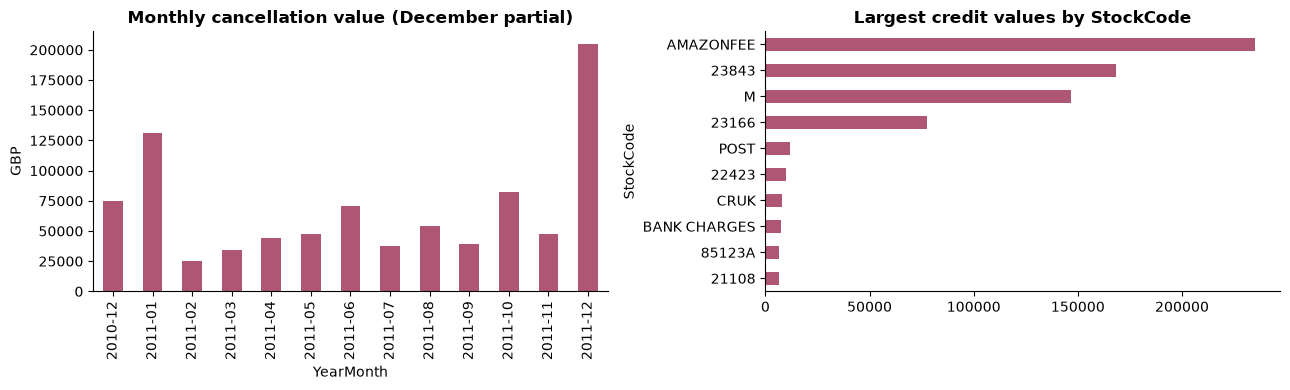

In [102]:
business_kpis = pd.Series(kpis(retail))
display(business_kpis.round(2))
cancellation_products = performance(retail, "StockCode").sort_values("CancellationValue", ascending=False)
cancellation_customers = customers_analysis.sort_values("CancellationValue", ascending=False)
display(cancellation_products.head(15).round(2))
display(cancellation_customers.head(15).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparable_monthly.CancellationValue.plot.bar(ax=axes[0], color="#AF5674", title="Monthly cancellation value (December partial)")
cancellation_products.head(10).sort_values("CancellationValue").CancellationValue.plot.barh(ax=axes[1], color="#AF5674", title="Largest credit values by StockCode")
for ax in axes: ax.set_ylabel("GBP" if ax == axes[0] else "StockCode")
fig.tight_layout()
plt.show()

### Invoice and basket analysis

Build one row per normal sales invoice. These are recorded gross invoice values before credits, including special lines. Show medians alongside means because extreme invoices can dominate averages. A logarithmic visualization retains large invoices without letting them obscure the typical distribution. It does not delete outliers.

,Revenue,Units,UniqueProducts,Lines
count,19959.00,19959.00,19959.00,19959.00
mean,532.64,279.19,26.03,26.30
std,1778.90,955.03,46.98,47.29
min,0.38,1.00,1.00,1.00
50%,303.30,150.00,15.00,15.00
90%,937.87,528.20,52.00,53.00
95%,1584.52,806.00,75.00,77.00
99%,4804.27,2233.26,217.42,218.00
max,168469.60,80995.00,1108.00,1114.00


,InvoiceDate,CustomerID,Revenue,Units,UniqueProducts,Lines
InvoiceNo,,,,,,
581483,2011-12-09 09:15:00,16446,168469.60,80995,1,1
541431,2011-01-18 10:01:00,12346,77183.60,74215,1,1
574941,2011-11-07 17:42:00,<NA>,52940.94,14149,101,101
576365,2011-11-14 17:55:00,<NA>,50653.91,13956,99,99
556444,2011-06-10 15:28:00,15098,38970.00,60,1,1
567423,2011-09-20 11:05:00,17450,31698.16,12572,12,12
556917,2011-06-15 13:37:00,12415,22775.93,15049,138,138
572209,2011-10-21 12:08:00,18102,22206.00,1920,7,7
567381,2011-09-20 10:12:00,17450,22104.80,6760,12,12


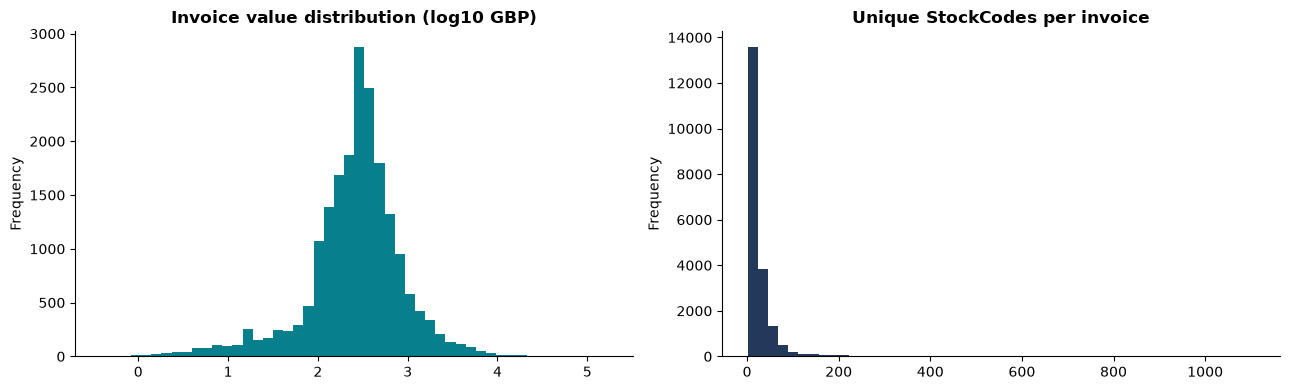

,InvoiceNo,StockCode,CustomerID,Quantity,Revenue
61619,541431,23166,12346,74215,77183.6
61624,C541433,23166,12346,-74215,-77183.6
540421,581483,23843,16446,80995,168469.6
540422,C581484,23843,16446,-80995,-168469.6


In [103]:
baskets = basket_summary(retail)
display(baskets[["Revenue", "Units", "UniqueProducts", "Lines"]].describe(percentiles=[.5, .9, .95, .99]).round(2))
display(baskets.nlargest(10, "Revenue"))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
np.log10(baskets.Revenue).plot.hist(bins=50, ax=axes[0], color="#087F8C", title="Invoice value distribution (log10 GBP)")
baskets.UniqueProducts.plot.hist(bins=50, ax=axes[1], color="#23395B", title="Unique StockCodes per invoice")
fig.tight_layout()
plt.show()
known_reversals = retail.loc[retail.InvoiceNo.isin(["581483", "C581484", "541431", "C541433"]),
    ["InvoiceNo", "StockCode", "CustomerID", "Quantity", "Revenue"]]
display(known_reversals)
assert known_reversals.groupby("StockCode").Revenue.sum().abs().lt(1e-8).all()

### Business insights: finding → evidence → interpretation → limitation

The following statements are generated from the actual analysis tables. Proposed actions are testable hypotheses; no causal effect, profit margin or forecast is inferred.

In [104]:
uk_share = country_performance.loc["United Kingdom", "NetRevenueSharePct"]
top_product = product_performance.iloc[0]
nov_growth = comparable_monthly.loc[pd.Period("2011-11"), "MoMPercent"]
insights = [
    {"Finding": "Revenue is concentrated in the UK", "Evidence": f"UK contributes {uk_share:.1f}% of retained net revenue",
     "Interpretation": "Prioritize service reliability in the largest recorded market; assess overseas opportunities separately",
     "Limitation": "Revenue is not profit; market size and acquisition costs are unavailable"},
    {"Finding": "November activity rises before the partial December period", "Evidence": f"November net revenue is GBP {monthly_sales.loc['2011-11']:,.2f}, up {nov_growth:.1f}% from October",
     "Interpretation": "Investigate inventory and fulfillment capacity around this observed peak",
     "Limitation": "One annual cycle cannot prove recurring seasonality or promotional causality"},
    {"Finding": "A small number of catalog products lead revenue", "Evidence": f"Top StockCode {product_performance.index[0]} contributes GBP {top_product.NetRevenue:,.2f}; top 10 account for {product_performance.head(10).NetRevenue.sum() / catalog.Revenue.sum() * 100:.1f}% of catalog net revenue",
     "Interpretation": "Review availability of leading products and test related-product recommendations",
     "Limitation": "Catalog membership is a StockCode proxy; margins and stock-outs are unknown"},
    {"Finding": "Repeat purchasing is observable among identified buyers", "Evidence": f"{purchasers.RepeatPurchaser.mean() * 100:.1f}% of {len(purchasers):,} purchasing customers have at least two sales invoices",
     "Interpretation": "Use RFM groups to design measurable retention experiments",
     "Limitation": f"{retail.CustomerID.isna().mean() * 100:.1f}% of lines lack CustomerID; behavior outside the window is unobserved"},
    {"Finding": "Credits materially separate gross from net revenue", "Evidence": f"Cancellation value is GBP {retail.CancellationValue.sum():,.2f}, or {business_kpis['Cancellation value / gross sales']:.1f}% of gross normal sales",
     "Interpretation": "Investigate high-credit products, customers and special fees before attributing causes",
     "Limitation": "Credits are not linked to original orders and include operational records"},
    {"Finding": "Large reversed invoices skew average basket value", "Evidence": f"Median invoice is GBP {baskets.Revenue.median():,.2f}, versus mean GBP {baskets.Revenue.mean():,.2f}; the two investigated sale/credit pairs net to zero",
     "Interpretation": "Use the median and distribution when describing typical recorded baskets",
     "Limitation": "Gross baskets retain later-cancelled sales and include special lines"},
]
business_insights = pd.DataFrame(insights)
display(business_insights)
for insight in insights:
    display(Markdown("**" + insight["Finding"] + "**  \n" + " → ".join([insight["Evidence"], insight["Interpretation"], insight["Limitation"]])))

,Finding,Evidence,Interpretation,Limitation
0,Revenue is concentrated in the UK,UK contributes 84.0% of retained net revenue,Prioritize service reliability in the largest ...,Revenue is not profit; market size and acquisi...
1,November activity rises before the partial Dec...,"November net revenue is GBP 1,456,145.80, up 3...",Investigate inventory and fulfillment capacity...,One annual cycle cannot prove recurring season...
2,A small number of catalog products lead revenue,"Top StockCode 22423 contributes GBP 164,459.49...",Review availability of leading products and te...,Catalog membership is a StockCode proxy; margi...
3,Repeat purchasing is observable among identifi...,"65.6% of 4,338 purchasing customers have at le...",Use RFM groups to design measurable retention ...,24.8% of lines lack CustomerID; behavior outsi...
4,Credits materially separate gross from net rev...,"Cancellation value is GBP 893,979.73, or 8.4% ...","Investigate high-credit products, customers an...",Credits are not linked to original orders and ...
5,Large reversed invoices skew average basket value,"Median invoice is GBP 303.30, versus mean GBP ...",Use the median and distribution when describin...,Gross baskets retain later-cancelled sales and...


**Revenue is concentrated in the UK**  
UK contributes 84.0% of retained net revenue → Prioritize service reliability in the largest recorded market; assess overseas opportunities separately → Revenue is not profit; market size and acquisition costs are unavailable

**November activity rises before the partial December period**  
November net revenue is GBP 1,456,145.80, up 36.2% from October → Investigate inventory and fulfillment capacity around this observed peak → One annual cycle cannot prove recurring seasonality or promotional causality

**A small number of catalog products lead revenue**  
Top StockCode 22423 contributes GBP 164,459.49; top 10 account for 8.2% of catalog net revenue → Review availability of leading products and test related-product recommendations → Catalog membership is a StockCode proxy; margins and stock-outs are unknown

**Repeat purchasing is observable among identified buyers**  
65.6% of 4,338 purchasing customers have at least two sales invoices → Use RFM groups to design measurable retention experiments → 24.8% of lines lack CustomerID; behavior outside the window is unobserved

**Credits materially separate gross from net revenue**  
Cancellation value is GBP 893,979.73, or 8.4% of gross normal sales → Investigate high-credit products, customers and special fees before attributing causes → Credits are not linked to original orders and include operational records

**Large reversed invoices skew average basket value**  
Median invoice is GBP 303.30, versus mean GBP 532.64; the two investigated sale/credit pairs net to zero → Use the median and distribution when describing typical recorded baskets → Gross baskets retain later-cancelled sales and include special lines

0### Dashboard, validation and project completion

Run `python -m streamlit run dashboard/app.py` from the project root. The separate app offers date, country, product, customer and RFM filters; reset; KPI definitions; interactive charts; downloadable analysis tables; and explicit empty-selection states. All activity measures use the filtered transactions. RFM is an as-of history snapshot through the selected end date, then restricted to customers active in the current view.

The shared pipeline is checked against the original `df_clean` above. Revenue components reconcile, known reversals are retained, full-month growth excludes December 2011, and RFM uses no future data. Automated checks live in `tests/`; run `python -m pytest -q` from the root.

All requested descriptive analytics stages are now covered in this notebook, with dashboard code and setup instructions in `README.md`. Predictive modeling is not part of the stated goal. Further work would require costs/margins, promotion history, reliable return-to-order links and a longer time series.